
# Petrophysically guided inversion (PGI): Linear example

We do a comparison between the classic least-squares inversion
and our formulation of a petrophysically constrained inversion.
We explore it through the UBC linear example.


## Tikhonov Inversion#



In [1]:
import discretize as Mesh
import matplotlib.pyplot as plt
import numpy as np
from simpeg import (
    data_misfit,
    directives,
    inverse_problem,
    inversion,
    maps,
    optimization,
    regularization,
    simulation,
    utils,
)

# Random seed for reproductibility
np.random.seed(1)
# Mesh
N = 100
mesh = Mesh.TensorMesh([N])

# Survey design parameters
nk = 20
jk = np.linspace(1.0, 60.0, nk)
p = -0.25
q = 0.25


# Physics
def g(k):
    return np.exp(p * jk[k] * mesh.cell_centers_x) * np.cos(
        np.pi * q * jk[k] * mesh.cell_centers_x
    )


G = np.empty((nk, mesh.nC))

for i in range(nk):
    G[i, :] = g(i)

# True model
mtrue = np.zeros(mesh.nC)
mtrue[mesh.cell_centers_x > 0.2] = 1.0
mtrue[mesh.cell_centers_x > 0.35] = 0.0
t = (mesh.cell_centers_x - 0.65) / 0.25
indx = np.abs(t) < 1
mtrue[indx] = -(((1 - t**2.0) ** 2.0)[indx])

mtrue = np.zeros(mesh.nC)
mtrue[mesh.cell_centers_x > 0.3] = 1.0
mtrue[mesh.cell_centers_x > 0.45] = -0.5
mtrue[mesh.cell_centers_x > 0.6] = 0

# simpeg problem and survey
prob = simulation.LinearSimulation(mesh, G=G, model_map=maps.IdentityMap())
std = 0.01
survey = prob.make_synthetic_data(mtrue, relative_error=std, add_noise=True)

# Setup the inverse problem
reg = regularization.WeightedLeastSquares(mesh, alpha_s=1.0, alpha_x=1.0)
dmis = data_misfit.L2DataMisfit(data=survey, simulation=prob)
opt = optimization.ProjectedGNCG(maxIter=10, cg_maxiter=50, cg_rtol=1e-3)
invProb = inverse_problem.BaseInvProblem(dmis, reg, opt)
directiveslist = [
    directives.BetaEstimate_ByEig(beta0_ratio=1e-5),
    directives.BetaSchedule(coolingFactor=10.0, coolingRate=2),
    directives.TargetMisfit(),
]

inv = inversion.BaseInversion(invProb, directiveList=directiveslist)
m0 = np.zeros_like(mtrue)

mnormal = inv.run(m0)

INFO: simpeg.InvProblem will set Regularization.reference_model to m0.
INFO: simpeg.InvProblem will set Regularization.reference_model to m0.
INFO: simpeg.InvProblem will set Regularization.reference_model to m0.
INFO: 
simpeg.InvProblem is setting bfgsH0 to the inverse of the reg.deriv2.
using the default solver Pardiso with the 'is_symmetric=True` option set.

INFO: Directive TargetMisfit: Target data misfit is 20.0



Running inversion with SimPEG v0.25.0
================================================= Projected GNCG =================================================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS   iter_CG   CG |Ax-b|/|b|  CG |Ax-b|   Comment   
-----------------------------------------------------------------------------------------------------------------
   0  1.83e+01  2.00e+05  0.00e+00  2.00e+05                         0           inf          inf                
   1  1.83e+01  3.06e+02  4.16e+01  1.06e+03    2.43e+06      0      13       7.27e-04     1.76e+03              
   2  1.83e+01  2.77e+01  4.47e+01  8.44e+02    1.76e+03      0      24       7.00e-05     1.23e-01              
   3  1.83e+00  4.28e+00  4.73e+01  9.05e+01    4.96e+02      0      50       1.70e+01     8.43e+03   Skip BFGS  
------------------------- STOP! -------------------------
1 : |fc-fOld| = 1.8768e+01 <= tolF*(1+|f0|) = 2.0000e+04
0 : |xc-x_last| = 1.6240e-01 <= tolX*(1+|x0|) =

## Petrophysically constrained inversion #



c:\Users\81805\anaconda3\envs\env_ubcgif\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\81805\anaconda3\envs\env_ubcgif\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\81805\anaconda3\envs\env_ubcgif\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
INFO: simpeg.InvProblem will set Regularization.reference_model to m0.
INFO: simpeg.InvP


Running inversion with SimPEG v0.25.0
Alpha scales: [np.float64(0.5179430933996889), np.float64(0.0)]
<class 'simpeg.regularization.pgi.PGIsmallness'>
================================================= Projected GNCG =================================================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS   iter_CG   CG |Ax-b|/|b|  CG |Ax-b|   Comment   
-----------------------------------------------------------------------------------------------------------------
   0  3.23e-02  2.00e+05  0.00e+00  2.00e+05                         0           inf          inf                
   1  3.23e-02  1.99e+01  3.50e+02  3.12e+01    2.43e+06      0      14       1.29e-04     3.12e+02              
geophys. misfits: 19.9 (target 20.0 [True]) | smallness misfit: 2966.7 (target: 100.0 [False])
mref changed in  26  places
Beta cooling evaluation: progress: [19.9]; minimum progress targets: [160000.]
Warming alpha_pgi to favor clustering:  1.0040379027505009
   2  3.23e-02  

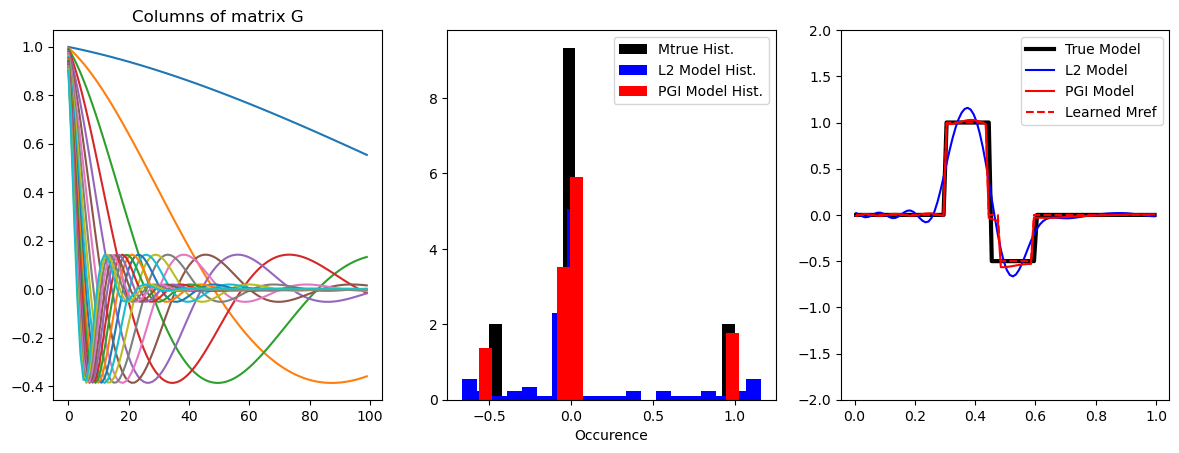

In [2]:
# fit a Gaussian Mixture Model with n components
# on the true model to simulate the laboratory
# petrophysical measurements
n = 3
clf = utils.WeightedGaussianMixture(
    mesh=mesh,
    n_components=n,
    covariance_type="full",
    max_iter=100,
    n_init=3,
    reg_covar=5e-4,
)
clf.fit(mtrue.reshape(-1, 1))

# Petrophyically constrained regularization
reg = regularization.PGI(
    gmmref=clf,
    mesh=mesh,
    alpha_pgi=1.0,
    alpha_x=1.0,
)

# Optimization
opt = optimization.ProjectedGNCG(maxIter=20, cg_maxiter=50, cg_rtol=1e-3)
opt.remember("xc")

# Setup new inverse problem
invProb = inverse_problem.BaseInvProblem(dmis, reg, opt)

# directives
Alphas = directives.AlphasSmoothEstimate_ByEig(alpha0_ratio=10.0, verbose=True)
beta = directives.BetaEstimate_ByEig(beta0_ratio=1e-8)
betaIt = directives.PGI_BetaAlphaSchedule(
    verbose=True,
    coolingFactor=2.0,
    warmingFactor=1.0,
    tolerance=0.1,
    update_rate=1,
    progress=0.2,
)
targets = directives.MultiTargetMisfits(verbose=True)
petrodir = directives.PGI_UpdateParameters()
addmref = directives.PGI_AddMrefInSmooth(verbose=True)

# Setup Inversion
inv = inversion.BaseInversion(
    invProb, directiveList=[Alphas, beta, petrodir, targets, addmref, betaIt]
)

# Initial model same as for WeightedLeastSquares
mcluster = inv.run(m0)

# Final Plot
fig, axes = plt.subplots(1, 3, figsize=(12 * 1.2, 4 * 1.2))
for i in range(prob.G.shape[0]):
    axes[0].plot(prob.G[i, :])
axes[0].set_title("Columns of matrix G")

axes[1].hist(mtrue, bins=20, linewidth=3.0, density=True, color="k")
axes[1].set_xlabel("Model value")
axes[1].set_xlabel("Occurence")
axes[1].hist(mnormal, bins=20, density=True, color="b")
axes[1].hist(mcluster, bins=20, density=True, color="r")
axes[1].legend(["Mtrue Hist.", "L2 Model Hist.", "PGI Model Hist."])

axes[2].plot(mesh.cell_centers_x, mtrue, color="black", linewidth=3)
axes[2].plot(mesh.cell_centers_x, mnormal, color="blue")
axes[2].plot(mesh.cell_centers_x, mcluster, "r-")
axes[2].plot(mesh.cell_centers_x, invProb.reg.objfcts[0].reference_model, "r--")

axes[2].legend(("True Model", "L2 Model", "PGI Model", "Learned Mref"))
axes[2].set_ylim([-2, 2])

plt.show()